In [1]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Helvetica'] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
import math

import pandas as pd


import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
import fly_plot_lib.plot as fpl

# Set condition

In [3]:
condition = 'unsteady'

In [4]:
def clean_labels(ax, show_labels, spines=['left', 'bottom']):
    #set_selective_rasterization(ax, rasterize_markers=['.'], raster_zorder=-1)
    #set_selective_rasterization(ax, rasterize_collections=[mcollections.PolyCollection], raster_zorder=-2)
    ax.set_rasterization_zorder(0)

    ax.set_yticks([0, 0.1, 0.2])
    ax.set_ylim(0, 0.2)
    ax.set_xlim(0, 5)
    ax.set_xticks([1,2,3,4])

    if show_labels:
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels([])
    
    if show_labels:
        ax.set_yticklabels([0, 0.1, 0.2])
    else:
        ax.set_yticklabels([])
        
    fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])
    
    if show_labels:
        ax.set_ylabel('Normalized\nmutual information', labelpad=1)
        ax.set_xlabel('')
    else:
        ax.set_ylabel('')
        ax.set_xlabel('')
    
    ax.tick_params(axis='y', pad=2)
    ax.tick_params(axis='x', pad=2)
    
    fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                     tick_length=2.5,
                                     spine_locations={'left': 5, 'bottom': 5},
                                     linewidth=0.5)
    fifi.mpl_functions.set_fontsize(ax, 6)

In [5]:
def mean_angle(angle):
    
    mean = np.arctan2( np.nanmean(np.sin(angle)), np.nanmean(np.cos(angle)) )
    return mean

def angle_distance(angle1, angle2):
    """
    Calculate the minimum distance between two angles.

    Parameters:
    -----------
    angle1, angle2 : float or array-like
        Angles in radians

    Returns:
    --------
    float or array
        Minimum distance between angles in radians 
        Range: [-π, π]
    """
    diff = angle1 - angle2
    # Wrap to [-π, π]
    distance = np.arctan2(np.sin(diff), np.cos(diff))
    return distance

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy as scipy_entropy

def analyze_phase_time_structure(data, time_axis=None, n_bins_phase=30, n_bins_time=30, 
                                  plot=True, y_range=(-np.pi, np.pi), bootstrap=True, 
                                 bootstrap_iterations=1000, bootstrap_subset_fraction=0.8):
    """
    Analyze structure in phase-vs-time data via 2D histogram entropy and mutual information.
    
    Parameters
    ----------
    data : np.ndarray, shape (n_trials, n_timepoints)
        Each row is one trial; values are phase (y-axis) at each timepoint.
    time_axis : np.ndarray, shape (n_timepoints,), optional
        Time values for x-axis. Defaults to range(n_timepoints).
    n_bins_phase : int
        Number of histogram bins along the phase axis.
    n_bins_time : int
        Number of histogram bins along the time axis.
    plot : bool
        Whether to plot the 2D histogram.
    y_range : tuple
        (min, max) for phase binning. Default (-pi, pi).
    
    Returns
    -------
    results : dict with keys:
        'entropy_2d'       : Shannon entropy of the 2D joint distribution
        'mutual_information': MI between phase and time
        'H_phase'          : marginal entropy of phase
        'H_time'           : marginal entropy of time
        'hist2d'           : 2D normalized histogram (phase x time)
        'phase_edges'      : bin edges for phase axis
        'time_edges'       : bin edges for time axis
    """
    n_trials, n_timepoints = data.shape
    
    if time_axis is None:
        time_axis = np.arange(n_timepoints)

    def calc_MI(data, time_axis, n_trials):
        # Repeat time axis for each trial to get flat arrays for histogram
        time_flat = np.tile(time_axis, n_trials)       # shape: (n_trials * n_timepoints,)
        phase_flat = data.flatten()                     # shape: (n_trials * n_timepoints,)
        
        # 2D histogram — note: np.histogram2d returns (time, phase) if we pass (time, phase)
        # We want hist[phase_bin, time_bin], so pass phase first
        hist2d, phase_edges, time_edges = np.histogram2d(
            phase_flat, time_flat,
            bins=[n_bins_phase, n_bins_time],
            range=[y_range, [time_axis.min(), time_axis.max()]]
        )
        
        # Normalize to get joint probability distribution P(phase, time)
        joint = hist2d / hist2d.sum()
        
        # --- Entropy calculations ---
        # Joint entropy H(phase, time)
        joint_flat = joint.flatten()
        joint_flat = joint_flat[joint_flat > 0]  # avoid log(0)
        H_joint = scipy_entropy(joint_flat)      # uses natural log by default; pass base=2 for bits
        
        # Marginal distributions
        p_phase = joint.sum(axis=1)  # sum over time bins
        p_time  = joint.sum(axis=0)  # sum over phase bins
        
        H_phase = scipy_entropy(p_phase[p_phase > 0])
        H_time  = scipy_entropy(p_time[p_time > 0])
        
        # Mutual information I(phase; time) = H(phase) + H(time) - H(phase, time)
        MI = H_phase + H_time - H_joint

        return hist2d, phase_edges, time_edges, joint, MI, H_phase, H_time, H_joint

    hist2d, phase_edges, time_edges, joint, MI, H_phase, H_time, H_joint = calc_MI(data, time_axis, n_trials)
    print(f"Observed MI full data set: {MI:.4f}")

    if bootstrap:
        subset_size = int(bootstrap_subset_fraction*n_trials)
        MI_bootstrap = []
        for i in range(bootstrap_iterations):
            rows = np.random.choice(np.arange(0, n_trials), subset_size, replace=False)
            data_boot = np.vstack([data[row,:] for row in rows])
            _, _, _, _, MIb, _, _, _ = calc_MI(data_boot, time_axis, subset_size)
            MI_bootstrap.append(MIb)
            #print(f"Bootstrap {i}: MI={MIb:.4f}, unique_rows={len(np.unique(rows))}")
        
        #print(f"Bootstrap mean: {np.mean(MI_bootstrap):.4f}")
        #print(f"Observed vs bootstrap mean difference: {MI - np.mean(MI_bootstrap):.4f}")

        rows = np.random.choice(np.arange(0, n_trials), subset_size, replace=False)
        data_boot = np.vstack([data[row,:] for row in rows])
        hist2d, phase_edges, time_edges, joint, MI, H_phase, H_time, H_joint = calc_MI(data_boot, time_axis, subset_size)
        print(f"Observed MI boostrap subset size: {MI:.4f}")

    # --- Optional plot ---
    if plot:
        ncols = 2 if bootstrap else 1
        fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4))
        if ncols == 1:
            axes = [axes]
            
        # pcolormesh expects (time, phase) orientation for imshow-like display
        # Use time on x-axis, phase on y-axis
        time_centers = 0.5 * (time_edges[:-1] + time_edges[1:])
        phase_centers = 0.5 * (phase_edges[:-1] + phase_edges[1:])
        TT, PP = np.meshgrid(time_centers, phase_centers)
        axes[0].pcolormesh(TT, PP, joint, cmap='inferno')
        axes[0].set_xlabel('Aligned time (s)')
        axes[0].set_ylabel('Phase')
        axes[0].set_yticks([-np.pi, 0, np.pi])
        axes[0].set_yticklabels([r'$-\pi$', '0', r'$\pi$'])
        axes[0].set_title(f'H(joint)={H_joint:.3f}, MI={MI:.3f}')
        

        if bootstrap:
            ci_low, ci_high = np.percentile(MI_bootstrap, [2.5, 97.5])
            axes[1].hist(MI_bootstrap, bins=40, color='steelblue', edgecolor='white')
            axes[1].axvline(MI, color='red', linewidth=2, label=f'Observed MI={MI:.3f}')
            axes[1].axvline(ci_low,  color='red', linewidth=1, linestyle='--',
                            label=f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')
            axes[1].axvline(ci_high, color='red', linewidth=1, linestyle='--')
            axes[1].set_xlabel('Mutual information (nats)')
            axes[1].set_ylabel('Count')
            axes[1].set_title(f'Bootstrap MI distribution (n={bootstrap_iterations})')
            axes[1].legend(fontsize=8)

        plt.tight_layout()
        plt.show()
    
    results = {
        'entropy_2d': H_joint,
        'mutual_information': MI,
        'H_phase': H_phase,
        'H_time': H_time,
        'hist2d': joint,
        'phase_edges': phase_edges,
        'time_edges': time_edges,
    }

    if bootstrap:
        results['MI_bootstrap'] = MI_bootstrap

    return results

In [7]:
import sys
import os
from pathlib import Path


def _uar(p):
    """Resolve a Unifying_Algo_Results path. Results shared with the main figure
    live in Main/; only supplemental-specific extras live in Supplemental/. If a
    Supplemental/ path is requested but the file lives in Main/, redirect to Main/."""
    p = str(p)
    if '/Supplemental/' in p:
        _main = p.replace('/Supplemental/', '/Main/')
        if os.path.exists(_main):
            return _main
    return p


In [8]:
from align_course_direction_analysis import unifying_algo_analysis as uaa
from align_course_direction_analysis import unifying_algo_plots as uap

In [9]:
def angle_distance(angle1, angle2):
    """
    Calculate the minimum distance between two angles.

    Parameters:
    -----------
    angle1, angle2 : float or array-like
        Angles in radians

    Returns:
    --------
    float or array
        Minimum distance between angles in radians 
        Range: [-π, π]
    """
    diff = angle1 - angle2
    # Wrap to [-π, π]
    distance = np.arctan2(np.sin(diff), np.cos(diff))
    return distance

In [10]:
COURSE_MARKER_SIZE = 2
COURSE_ALPHA_MULTIPLIER = 3

TRANSLATION = True

FIGURE_NAME = 'supplemental_unifying_analysis_flies.svg'

In [11]:
def get_median_slope_and_axis_ratio(fname):
    df = pd.read_parquet(_uar(fname))

    slopes = []
    axis_ratios = []
    rotation = []
    rho = []

    for obj_id in df.obj_id_unique_event.unique():
        data = df[df.obj_id_unique_event==obj_id].copy()
        #slopes.append(data.slope.abs().median())

        data['slope_abs'] = data.slope.abs()
        slopes.append( uaa.get_weighted_value(data, col='slope_abs', use='rmse_affine') )

        axis_ratios.append( uaa.get_weighted_value(data, col='axis_ratio', use='rmse_affine') )

        data.rotation = data.rotation.abs()
        rotation.append( uaa.get_weighted_value(data, col='rotation', use='rmse_affine') )

        data.rho = data.rho.abs()
        rho.append( uaa.get_weighted_value(data, col='rho', use='rmse_affine') )

            
    results = {'slopes': np.array(slopes)/0.01,
               'axis_ratios': np.array(axis_ratios),
               'rotation': np.array(rotation),
               'rho': np.array(rho),
               #'percent_affine_improvements': np.array(percent_affine_improvements),
              }
    
    return results

# C1xWT Sham

In [12]:
xtick = 2
color = 'gray'

In [13]:
if condition == 'laminar':
    df = pd.read_hdf(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_laminar_c1xwt_preprocessed_optotrigger_trimmed.hdf')
    fname = 'laminar_data_sham_translation' + str(TRANSLATION) + '.parquet'

if condition == 'stillair':
    df = pd.read_hdf(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_stillair_c1xwt_preprocessed_optotrigger_trimmed.hdf')
    fname = 'stillair_data_sham_translation' + str(TRANSLATION) + '.parquet'

if condition == 'unsteady':
    df = pd.read_parquet(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED_merged.parquet')
    fname = 'unsteady_top_on_data_sham_AUGMENTED_translation' + str(TRANSLATION) + '.parquet'

unifying_algo_data = pd.read_parquet(_uar(str(Path('../../../Data/Unifying_Algo_Results/Supplemental')) + '/' + fname))
slopes_sham = get_median_slope_and_axis_ratio(str(Path('../../../Data/Unifying_Algo_Results/Supplemental')) + '/' + fname)['slopes']

In [14]:
if 0:
    fig = plt.figure(figsize=(2,1))
    ax = fig.add_subplot(111)

# build aligned arrays
results = uaa.get_aligned_course_array(unifying_algo_data, df, return_linear_and_affine_fits=True)
ix_master, aligned_time_since_flash_arr, aligned_course_arr, aligned_roi_arr, aligned_linear_fits, aligned_affine_fits = results

# Mean affine fit
mean_affine_fit = [mean_angle(aligned_affine_fits[:,i]) for i in range(aligned_affine_fits.shape[1])]
mean_affine_fit = np.array(mean_affine_fit)
mean_affine_fit[0:200] = np.nan
mean_affine_fit[400:] = np.nan
mean_affine_fit = np.atleast_2d(np.array(mean_affine_fit))

# build flash arrays from aligned time
flash_length = 675 # ms
aligned_flash_arr = np.zeros_like(aligned_time_since_flash_arr)
ix = np.where( (aligned_time_since_flash_arr>0) * (aligned_time_since_flash_arr<flash_length/1000.) )
aligned_flash_arr[ix] = 1

# make the plot
if 0:
    uap.plot_aligned_course_from_array(ix_master, 
                                       aligned_time_since_flash_arr, 
                                       aligned_course_arr, 
                                       aligned_roi_arr,
                                       aligned_flash_arr=None,
                                       aligned_linear_fits=None, # if None, skips plot
                                       aligned_affine_fits=mean_affine_fit, # if None, skips plot
                                       xlim_start=-300,
                                       xlim_end=300,
                                       ax=ax,
                                       clean_spines=True,
                                       course_marker_size=COURSE_MARKER_SIZE,
                                       course_alpha_multiplier=COURSE_ALPHA_MULTIPLIER,
                                       )

/var/folders/63/jqdzyjdd4bnghtd7s779bx500000gp/T/ipykernel_11630/507308692.py:3: RuntimeWarning: Mean of empty slice
  mean = np.arctan2( np.nanmean(np.sin(angle)), np.nanmean(np.cos(angle)) )


In [15]:
aligned_course_arr_roi = aligned_course_arr[:,200:400]
mean_affine_fit_roi = mean_affine_fit[:,200:400]

In [16]:
aligned_course_arr_roi.shape

(85, 200)

In [17]:
result = analyze_phase_time_structure(aligned_course_arr_roi, time_axis=None, n_bins_phase=30, n_bins_time=30, 
                                  plot=False, y_range=(-np.pi, np.pi), bootstrap=True)
MI_sham = result['MI_bootstrap'] / min(result['H_phase'], result['H_time'])

Observed MI full data set: 0.0720


Observed MI boostrap subset size: 0.0837


In [18]:
rhos_sham = []
for i in range(aligned_course_arr_roi.shape[0]):
    ix = np.where(~np.isnan(aligned_course_arr_roi[i,:]))
    rhos_sham.append(uaa.get_circular_rho(aligned_course_arr_roi[i, ix], mean_affine_fit_roi[0, ix]))
rhos_sham = np.array(rhos_sham)

maes_sham = []
for i in range(aligned_course_arr_roi.shape[0]):
    ix = np.where(~np.isnan(aligned_course_arr_roi[i,:]))
    maes_sham.append(np.mean(np.abs(angle_distance(aligned_course_arr_roi[i, ix], mean_affine_fit_roi[0, ix]))))
maes_sham = np.array(maes_sham)

# C1xWT flash

In [19]:
if condition == 'laminar':
    df = pd.read_hdf(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_laminar_c1xwt_preprocessed_optotrigger_trimmed.hdf')
    fname = 'laminar_data_flash_translation' + str(TRANSLATION) + '.parquet'

if condition == 'stillair':
    df = pd.read_hdf(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_stillair_c1xwt_preprocessed_optotrigger_trimmed.hdf')
    fname = 'stillair_data_flash_translation' + str(TRANSLATION) + '.parquet'

if condition == 'unsteady':
    df = pd.read_hdf(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed.hdf')
    fname = 'unsteady_top_on_data_flash_translation' + str(TRANSLATION) + '.parquet'

unifying_algo_data = pd.read_parquet(_uar(str(Path('../../../Data/Unifying_Algo_Results/Supplemental')) + '/' + fname))
slopes_flash = get_median_slope_and_axis_ratio(str(Path('../../../Data/Unifying_Algo_Results/Supplemental')) + '/' + fname)['slopes']

In [20]:
if 0:
    fig = plt.figure(figsize=(3,2))
    ax = fig.add_subplot(111)

# build aligned arrays
results = uaa.get_aligned_course_array(unifying_algo_data, df, return_linear_and_affine_fits=True)
ix_master, aligned_time_since_flash_arr, aligned_course_arr, aligned_roi_arr, aligned_linear_fits, aligned_affine_fits = results

# Mean affine fit
mean_affine_fit = [mean_angle(aligned_affine_fits[:,i]) for i in range(aligned_affine_fits.shape[1])]
mean_affine_fit = np.atleast_2d(np.array(mean_affine_fit))

# build flash arrays from aligned time
flash_length = 675 # ms
aligned_flash_arr = np.zeros_like(aligned_time_since_flash_arr)
ix = np.where( (aligned_time_since_flash_arr>0) * (aligned_time_since_flash_arr<flash_length/1000.) )
aligned_flash_arr[ix] = 1

# make the plot
if 0:
    uap.plot_aligned_course_from_array(ix_master, 
                                       aligned_time_since_flash_arr, 
                                       aligned_course_arr, 
                                       aligned_roi_arr,
                                       aligned_flash_arr=None,
                                       aligned_linear_fits=None, # if None, skips plot
                                       aligned_affine_fits=mean_affine_fit, # if None, skips plot
                                       xlim_start=-300,
                                       xlim_end=300,
                                       ax=ax,
                                       clean_spines=True,
                                       course_marker_size=COURSE_MARKER_SIZE,
                                       course_alpha_multiplier=COURSE_ALPHA_MULTIPLIER,
                                       )

/var/folders/63/jqdzyjdd4bnghtd7s779bx500000gp/T/ipykernel_11630/507308692.py:3: RuntimeWarning: Mean of empty slice
  mean = np.arctan2( np.nanmean(np.sin(angle)), np.nanmean(np.cos(angle)) )


In [21]:
aligned_course_arr_roi = aligned_course_arr[:,200:400]
mean_affine_fit_roi = mean_affine_fit[:,200:400]

Observed MI full data set: 0.3857


Observed MI boostrap subset size: 0.4049


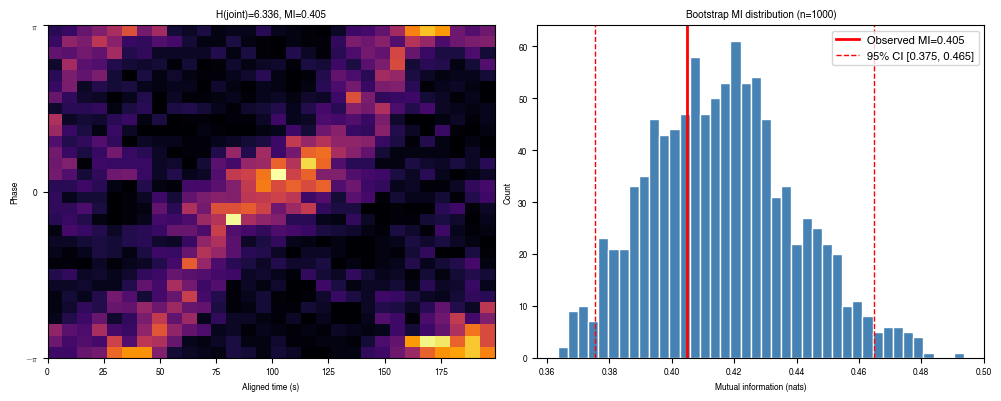

In [22]:
result = analyze_phase_time_structure(aligned_course_arr_roi, time_axis=None, n_bins_phase=30, n_bins_time=30, 
                                  plot=True, y_range=(-np.pi, np.pi), bootstrap=True)
MI_flash = result['MI_bootstrap'] / min(result['H_phase'], result['H_time'])

In [23]:
rhos_flash = []
for i in range(aligned_course_arr_roi.shape[0]):
    ix = np.where(~np.isnan(aligned_course_arr_roi[i,:]))
    rhos_flash.append(uaa.get_circular_rho(aligned_course_arr_roi[i, ix], mean_affine_fit_roi[0, ix]))
rhos_flash = np.array(rhos_flash)

maes_flash = []
for i in range(aligned_course_arr_roi.shape[0]):
    ix = np.where(~np.isnan(aligned_course_arr_roi[i,:]))
    maes_flash.append(np.mean(np.abs(angle_distance(aligned_course_arr_roi[i, ix], mean_affine_fit_roi[0, ix]))))
maes_flash = np.array(maes_flash)

# WT flash

In [24]:
fname = None

if condition == 'laminar':
    df = pd.read_hdf(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_laminar_wt_preprocessed_optotrigger_trimmed.hdf')
    fname = 'WT_laminar_data_flash_translation' + str(TRANSLATION) + '.parquet'

if condition == 'stillair':
    df = pd.read_hdf(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_stillair_wt_preprocessed_optotrigger_trimmed.hdf')
    fname = 'WT_stillair_data_flash_translation' + str(TRANSLATION) + '.parquet'

if condition == 'unsteady':
    df = pd.read_parquet(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_splitflow_topon_wt_preprocessed_optotrigger_trimmed.parquet')
    #fname = 'unsteady_top_on_data_WT_flash_translation' + str(TRANSLATION) + '.parquet'
    fname = 'experiencedunsteady_top_on_data_WT_flash_translation' + str(TRANSLATION) + '.parquet'

if fname is not None:
    unifying_algo_data = pd.read_parquet(_uar(str(Path('../../../Data/Unifying_Algo_Results/Supplemental')) + '/' + fname))
    slopes_WT_flash = get_median_slope_and_axis_ratio(str(Path('../../../Data/Unifying_Algo_Results/Supplemental')) + '/' + fname)['slopes']

In [25]:
if fname is not None:
    if 0:
        fig = plt.figure(figsize=(3,2))
        ax = fig.add_subplot(111)
    
    # build aligned arrays
    results = uaa.get_aligned_course_array(unifying_algo_data, df, return_linear_and_affine_fits=True)
    ix_master, aligned_time_since_flash_arr, aligned_course_arr, aligned_roi_arr, aligned_linear_fits, aligned_affine_fits = results
    
    # Mean affine fit
    mean_affine_fit = [mean_angle(aligned_affine_fits[:,i]) for i in range(aligned_affine_fits.shape[1])]
    mean_affine_fit = np.atleast_2d(np.array(mean_affine_fit))
    
    # build flash arrays from aligned time
    flash_length = 675 # ms
    aligned_flash_arr = np.zeros_like(aligned_time_since_flash_arr)
    ix = np.where( (aligned_time_since_flash_arr>0) * (aligned_time_since_flash_arr<flash_length/1000.) )
    aligned_flash_arr[ix] = 1
    
    # make the plot
    if 0:
        uap.plot_aligned_course_from_array(ix_master, 
                                           aligned_time_since_flash_arr, 
                                           aligned_course_arr, 
                                           aligned_roi_arr,
                                           aligned_flash_arr=None,
                                           aligned_linear_fits=None, # if None, skips plot
                                           aligned_affine_fits=mean_affine_fit, # if None, skips plot
                                           xlim_start=-300,
                                           xlim_end=300,
                                           ax=ax,
                                           clean_spines=True,
                                           course_marker_size=COURSE_MARKER_SIZE,
                                           course_alpha_multiplier=COURSE_ALPHA_MULTIPLIER,
                                           )

/var/folders/63/jqdzyjdd4bnghtd7s779bx500000gp/T/ipykernel_11630/507308692.py:3: RuntimeWarning: Mean of empty slice
  mean = np.arctan2( np.nanmean(np.sin(angle)), np.nanmean(np.cos(angle)) )


Observed MI full data set: 0.2091


Observed MI boostrap subset size: 0.2378


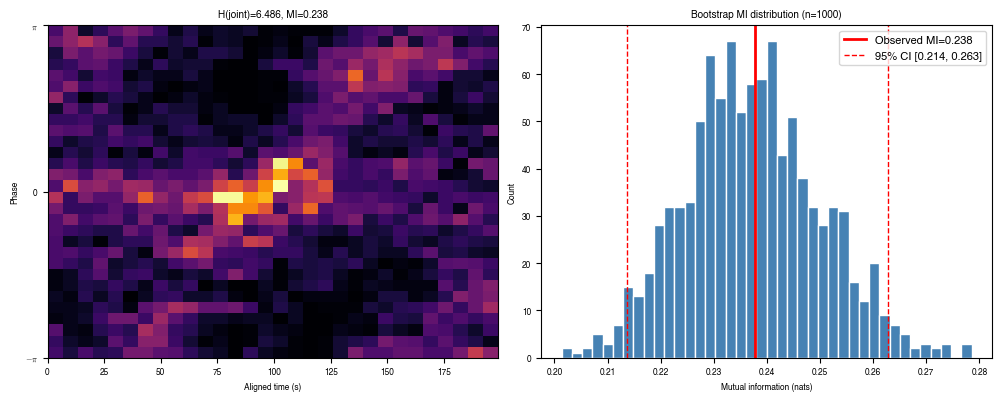

In [26]:
if fname is not None:
    aligned_course_arr_roi = aligned_course_arr[:,200:400]
    mean_affine_fit_roi = mean_affine_fit[:,200:400]
    
    result = analyze_phase_time_structure(aligned_course_arr_roi, time_axis=None, n_bins_phase=30, n_bins_time=30, 
                                  plot=True, y_range=(-np.pi, np.pi), bootstrap=True)
    MI_WT_flash = result['MI_bootstrap'] / min(result['H_phase'], result['H_time'])
    
else:
    MI_WT_flash = None

In [27]:
if fname is not None:
    aligned_course_arr_roi = aligned_course_arr[:,200:400]
    mean_affine_fit_roi = mean_affine_fit[:,200:400]
    
    rhos_WT_flash = []
    for i in range(aligned_course_arr_roi.shape[0]):
        ix = np.where(~np.isnan(aligned_course_arr_roi[i,:]))
        rhos_WT_flash.append(uaa.get_circular_rho(aligned_course_arr_roi[i, ix], mean_affine_fit_roi[0, ix]))
    rhos_WT_flash = np.array(rhos_WT_flash)


    maes_WT_flash = []
    for i in range(aligned_course_arr_roi.shape[0]):
        ix = np.where(~np.isnan(aligned_course_arr_roi[i,:]))
        maes_WT_flash.append(np.mean(np.abs(angle_distance(aligned_course_arr_roi[i, ix], mean_affine_fit_roi[0, ix]))))
    maes_WT_flash = np.array(maes_WT_flash)
else:
    rhos_WT_flash = None

# WT sham

In [28]:
fname = None

if condition == 'laminar':
    df = pd.read_hdf(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_laminar_wt_preprocessed_optotrigger_trimmed.hdf')
    fname = 'WT_laminar_data_sham_translation' + str(TRANSLATION) + '.parquet'

if condition == 'stillair':
    df = pd.read_hdf(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_stillair_wt_preprocessed_optotrigger_trimmed.hdf')
    fname = 'WT_stillair_data_sham_translation' + str(TRANSLATION) + '.parquet'

if condition == 'unsteady':
    df = pd.read_parquet(str(Path('../../../Data/Experimental_Fly_Data')) + '/flies_splitflow_topon_wt_preprocessed_optotrigger_trimmed.parquet')
    #fname = 'unsteady_top_on_data_WT_sham_translation' + str(TRANSLATION) + '.parquet'
    fname = 'experiencedunsteady_top_on_data_WT_sham_translation' + str(TRANSLATION) + '.parquet'

if fname is not None:
    unifying_algo_data = pd.read_parquet(_uar(str(Path('../../../Data/Unifying_Algo_Results/Supplemental')) + '/' + fname))
    slopes_WT_sham = get_median_slope_and_axis_ratio(str(Path('../../../Data/Unifying_Algo_Results/Supplemental')) + '/' + fname)['slopes']

In [29]:
if fname is not None:
    if 0:
        fig = plt.figure(figsize=(3,2))
        ax = fig.add_subplot(111)
    
    # build aligned arrays
    results = uaa.get_aligned_course_array(unifying_algo_data, df, return_linear_and_affine_fits=True)
    ix_master, aligned_time_since_flash_arr, aligned_course_arr, aligned_roi_arr, aligned_linear_fits, aligned_affine_fits = results
    
    # Mean affine fit
    mean_affine_fit = [mean_angle(aligned_affine_fits[:,i]) for i in range(aligned_affine_fits.shape[1])]
    mean_affine_fit = np.atleast_2d(np.array(mean_affine_fit))
    
    # build flash arrays from aligned time
    flash_length = 675 # ms
    aligned_flash_arr = np.zeros_like(aligned_time_since_flash_arr)
    ix = np.where( (aligned_time_since_flash_arr>0) * (aligned_time_since_flash_arr<flash_length/1000.) )
    aligned_flash_arr[ix] = 1
    
    # make the plot
    if 0:
        uap.plot_aligned_course_from_array(ix_master, 
                                           aligned_time_since_flash_arr, 
                                           aligned_course_arr, 
                                           aligned_roi_arr,
                                           aligned_flash_arr=None,
                                           aligned_linear_fits=None, # if None, skips plot
                                           aligned_affine_fits=mean_affine_fit, # if None, skips plot
                                           xlim_start=-300,
                                           xlim_end=300,
                                           ax=ax,
                                           clean_spines=True,
                                           course_marker_size=COURSE_MARKER_SIZE,
                                           course_alpha_multiplier=COURSE_ALPHA_MULTIPLIER,
                                           )

/var/folders/63/jqdzyjdd4bnghtd7s779bx500000gp/T/ipykernel_11630/507308692.py:3: RuntimeWarning: Mean of empty slice
  mean = np.arctan2( np.nanmean(np.sin(angle)), np.nanmean(np.cos(angle)) )


In [30]:
if fname is not None:
    aligned_course_arr_roi = aligned_course_arr[:,200:400]
    mean_affine_fit_roi = mean_affine_fit[:,200:400]

    result = analyze_phase_time_structure(aligned_course_arr_roi, time_axis=None, n_bins_phase=30, n_bins_time=30, 
                                  plot=False, y_range=(-np.pi, np.pi), bootstrap=True)
    MI_WT_sham = result['MI_bootstrap'] / min(result['H_phase'], result['H_time'])
    
    rhos_WT_sham = []
    for i in range(aligned_course_arr_roi.shape[0]):
        ix = np.where(~np.isnan(aligned_course_arr_roi[i,:]))
        rhos_WT_sham.append(uaa.get_circular_rho(aligned_course_arr_roi[i, ix], mean_affine_fit_roi[0, ix]))
    rhos_WT_sham = np.array(rhos_WT_sham)

    maes_WT_sham = []
    for i in range(aligned_course_arr_roi.shape[0]):
        ix = np.where(~np.isnan(aligned_course_arr_roi[i,:]))
        maes_WT_sham.append(np.mean(np.abs(angle_distance(aligned_course_arr_roi[i, ix], mean_affine_fit_roi[0, ix]))))
    maes_WT_sham = np.array(maes_WT_sham)
else:
    rhos_WT_sham = None
    MI_WT_sham = None

Observed MI full data set: 0.1835


Observed MI boostrap subset size: 0.2070


In [31]:
fifi_layout = True

In [32]:
if fifi_layout:
    layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
    plt.close('all')
    
    ax = layout.axes[(condition+'_mae', condition+'_mae')]
else:
    fig = plt.figure(figsize=(3,2))
    ax = fig.add_subplot(111)

In [33]:


MI_flash = np.array(MI_flash)
MI_sham = np.array(MI_sham)

if MI_WT_flash is not None:
    MI_WT_flash = np.array(MI_WT_flash)
if MI_WT_sham is not None:
    MI_WT_sham = np.array(MI_WT_sham)

xix = 1
ci_low, ci_high = np.percentile(MI_flash, [2.5, 97.5])
mean = np.mean(MI_flash)
ax.fill_betweenx([ci_low, ci_high], xix-0.3, xix+0.3, facecolor='red', alpha=0.3, edgecolor='none')
ax.hlines(mean, xix-0.3, xix+0.3, colors='red', alpha=1, linewidths=2)

xix = 2
ci_low, ci_high = np.percentile(MI_sham, [2.5, 97.5])
mean = np.mean(MI_sham)
ax.fill_betweenx([ci_low, ci_high], xix-0.3, xix+0.3, facecolor='gray', alpha=0.3, edgecolor='none')
ax.hlines(mean, xix-0.3, xix+0.3, colors='gray', alpha=1, linewidths=2)




if MI_WT_flash is not None:
    xix = 3
    ci_low, ci_high = np.percentile(MI_WT_flash, [2.5, 97.5])
    mean = np.mean(MI_WT_flash)
    ax.fill_betweenx([ci_low, ci_high], xix-0.3, xix+0.3, facecolor='darkgoldenrod', alpha=0.3, edgecolor='none')
    ax.hlines(mean, xix-0.3, xix+0.3, colors='darkgoldenrod', alpha=1, linewidths=2)

if MI_WT_sham is not None:
    xix = 4
    ci_low, ci_high = np.percentile(MI_WT_sham, [2.5, 97.5])
    mean = np.mean(MI_WT_sham)
    ax.fill_betweenx([ci_low, ci_high], xix-0.3, xix+0.3, facecolor='black', alpha=0.3, edgecolor='none')
    ax.hlines(mean, xix-0.3, xix+0.3, colors='black', alpha=1, linewidths=2)
    

if condition == 'laminar':
    clean_labels(ax, show_labels=True)
else:
    clean_labels(ax, show_labels=False)

In [34]:
if fifi_layout:
    layout.append_figure_to_layer(layout.figures[condition+'_mae'], condition+'_mae', cleartarget=True)
    layout.write_svg(FIGURE_NAME)